# Phase 2 — Advanced Neural Network with Regularisation

**Learning Goals**
- Build a deeper network with the Keras Functional API
- Apply Batch Normalization, Dropout, and L1/L2 regularisation
- Implement gradient clipping to prevent exploding gradients
- Use advanced callbacks (EarlyStopping, ReduceLROnPlateau)

**Tasks to complete:**
1. `TODO 5` in `src/models.py` — `build_advanced_nn()`
2. `TODO 9` in `src/train.py` — `get_callbacks()` (if not done in Phase 1)

Run `pytest tests/test_phase2.py -v` to check your work.

In [8]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from src.data_loader import get_data_generators, compute_class_weights
from src.train import get_callbacks, train_model, plot_history

In [9]:
train_gen, val_gen, test_gen = get_data_generators(
    data_dir='../data/chest_xray',
    img_size=(64, 64),
    batch_size=32,
)
class_weights = compute_class_weights(train_gen)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


## 1. Build the Advanced Network

Implement `build_advanced_nn()` in `src/models.py`.

**Architecture checklist:**
- [ ] Functional API (not Sequential)
- [ ] BatchNormalization after every Dense layer
- [ ] Dropout (experiment with rates 0.3, 0.4, 0.5)
- [ ] L2 regularisation on kernel weights
- [ ] Gradient clipping on the Adam optimizer

In [10]:
from src.models import build_advanced_nn

model = build_advanced_nn(
    input_shape=(64, 64, 3),
    dropout_rate=0.5,
    l2_lambda=1e-4,
    learning_rate=1e-3,
)
model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 64, 64, 3)]       0         
                                                                 
 flatten_2 (Flatten)         (None, 12288)             0         
                                                                 
 dense_10 (Dense)            (None, 512)               6291968   
                                                                 
 batch_normalization_8 (Bat  (None, 512)               2048      
 chNormalization)                                                
                                                                 
 dropout_4 (Dropout)         (None, 512)               0         
                                                                 
 dense_11 (Dense)            (None, 256)               131328    
                                                           

Epoch 1/30
163/163 [==============================] - 55s 320ms/step - loss: 0.6721 - accuracy: 0.7448 - auc: 0.8310 - val_loss: 1.1976 - val_accuracy: 0.7500 - val_auc: 0.5703 - lr: 0.0010


c:\Users\91900\Digicrome_Internship_080226_GenAI\Projects\Image_Classification_Medical_Diagnosis_3\image-classification-nagasantoshchavvakula-1\venv\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 2/30
163/163 [==============================] - 52s 320ms/step - loss: 0.5737 - accuracy: 0.8096 - auc: 0.8872 - val_loss: 0.7163 - val_accuracy: 0.6250 - val_auc: 0.8281 - lr: 0.0010
Epoch 3/30
163/163 [==============================] - 50s 309ms/step - loss: 0.5235 - accuracy: 0.8338 - auc: 0.9096 - val_loss: 0.8503 - val_accuracy: 0.5625 - val_auc: 0.6719 - lr: 0.0010
Epoch 4/30
163/163 [==============================] - 49s 303ms/step - loss: 0.5090 - accuracy: 0.8363 - auc: 0.9145 - val_loss: 0.7287 - val_accuracy: 0.7500 - val_auc: 0.7656 - lr: 0.0010
Epoch 5/30
163/163 [==============================] - 49s 299ms/step - loss: 0.4847 - accuracy: 0.8531 - auc: 0.9236 - val_loss: 1.1591 - val_accuracy: 0.5625 - val_auc: 0.6016 - lr: 0.0010
Epoch 6/30
163/163 [==============================] - 49s 301ms/step - loss: 0.4649 - accuracy: 0.8497 - auc: 0.9295 - val_loss: 0.7967 - val_accuracy: 0.6250 - val_auc: 0.7500 - lr: 5.0000e-04
Epoch 7/30
163/163 [==========================

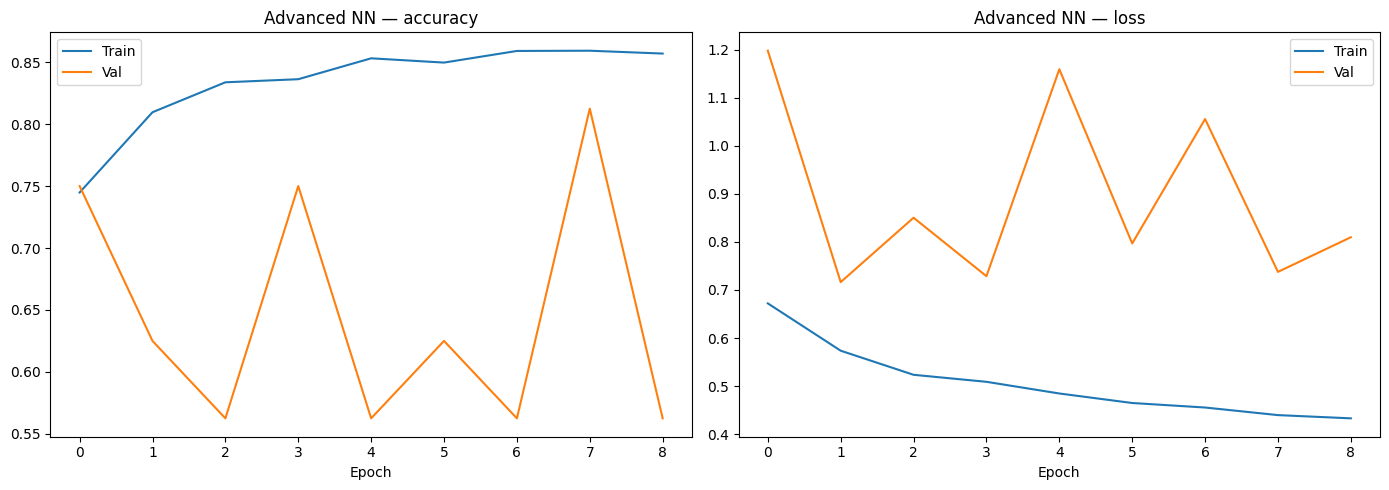

In [12]:
callbacks = get_callbacks(model_name='advanced_nn', patience=7)

history = train_model(
    model,
    train_gen,
    val_gen,
    epochs=30,
    class_weights=class_weights,
    callbacks=callbacks,
)
plot_history(history, title='Advanced NN')

## 2. Regularisation Ablation Study

Train three variants and compare:
- No regularisation
- L2 only
- L2 + Dropout + BatchNorm (full)

In [14]:
from src.models import build_baseline_mlp

configs = {
    'No reg':   dict(dropout_rate=0.0, l2_lambda=0.0),
    'L2 only':  dict(dropout_rate=0.0, l2_lambda=1e-4),
    'Full reg': dict(dropout_rate=0.5, l2_lambda=1e-4),
}

ablation_results = {}
for name, cfg in configs.items():
    m = build_advanced_nn(input_shape=(64, 64, 3), **cfg)
    h = train_model(m, train_gen, val_gen, epochs=15, class_weights=class_weights)
    ablation_results[name] = {
        'val_acc': max(h.history['val_accuracy']),
        'val_loss': min(h.history['val_loss']),
    }
    print(f"{name}: val_acc={ablation_results[name]['val_acc']:.4f}")

Epoch 1/15
163/163 [==============================] - 51s 296ms/step - loss: 0.4110 - accuracy: 0.8035 - auc: 0.8991 - val_loss: 2.1570 - val_accuracy: 0.6250 - val_auc: 0.6016
Epoch 2/15
163/163 [==============================] - 48s 294ms/step - loss: 0.3319 - accuracy: 0.8602 - auc: 0.9333 - val_loss: 0.8666 - val_accuracy: 0.5000 - val_auc: 0.5781
Epoch 3/15
163/163 [==============================] - 49s 303ms/step - loss: 0.3162 - accuracy: 0.8654 - auc: 0.9388 - val_loss: 1.0221 - val_accuracy: 0.5625 - val_auc: 0.8359
Epoch 4/15
163/163 [==============================] - 48s 295ms/step - loss: 0.2866 - accuracy: 0.8788 - auc: 0.9494 - val_loss: 1.0336 - val_accuracy: 0.6875 - val_auc: 0.8750
Epoch 5/15
163/163 [==============================] - 48s 297ms/step - loss: 0.2957 - accuracy: 0.8698 - auc: 0.9467 - val_loss: 0.5697 - val_accuracy: 0.7500 - val_auc: 0.9844
Epoch 6/15
163/163 [==============================] - 49s 300ms/step - loss: 0.2759 - accuracy: 0.8817 - auc: 0.953

## 3. Visualise Training vs Validation Loss Gap

A large gap indicates overfitting. Plot both runs side by side.

Epoch 1/5
163/163 [==============================] - 51s 299ms/step - loss: 0.4111 - accuracy: 0.8090 - auc: 0.8996 - val_loss: 0.9636 - val_accuracy: 0.7500 - val_auc: 0.5703
Epoch 2/5
163/163 [==============================] - 49s 298ms/step - loss: 0.3521 - accuracy: 0.8493 - auc: 0.9252 - val_loss: 1.0188 - val_accuracy: 0.5625 - val_auc: 0.7031
Epoch 3/5
163/163 [==============================] - 48s 297ms/step - loss: 0.2914 - accuracy: 0.8715 - auc: 0.9484 - val_loss: 0.6554 - val_accuracy: 0.6875 - val_auc: 0.8125
Epoch 4/5
163/163 [==============================] - 48s 296ms/step - loss: 0.3016 - accuracy: 0.8752 - auc: 0.9442 - val_loss: 0.7773 - val_accuracy: 0.7500 - val_auc: 0.7188
Epoch 5/5
163/163 [==============================] - 48s 295ms/step - loss: 0.2912 - accuracy: 0.8754 - auc: 0.9480 - val_loss: 0.5915 - val_accuracy: 0.8125 - val_auc: 0.7656


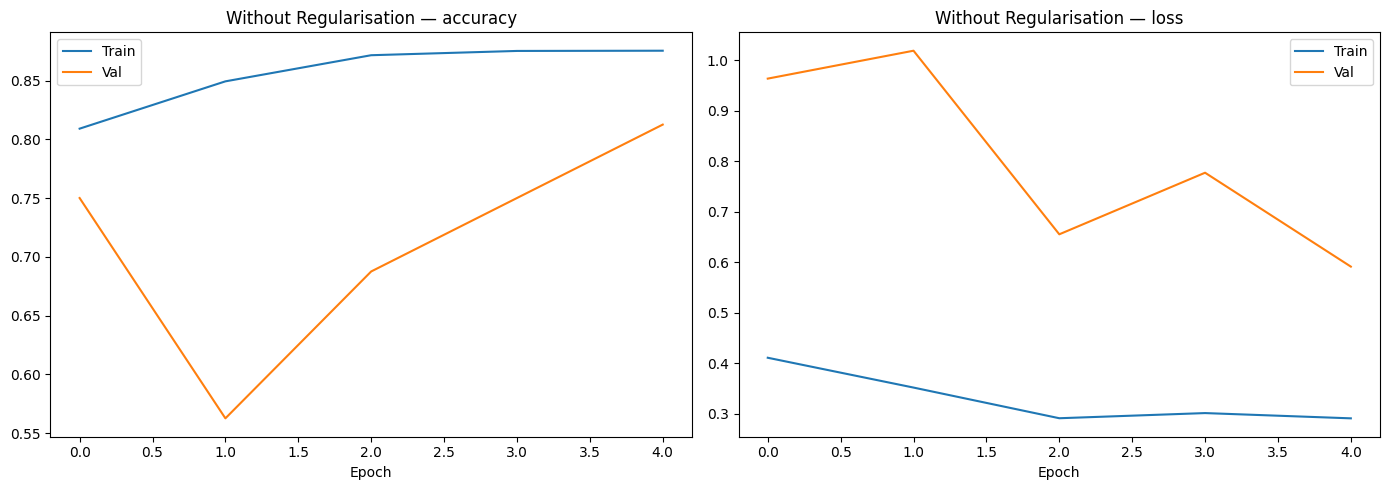

Epoch 1/5
163/163 [==============================] - 54s 321ms/step - loss: 0.6872 - accuracy: 0.7349 - auc: 0.8193 - val_loss: 1.5194 - val_accuracy: 0.6875 - val_auc: 0.5156
Epoch 2/5
163/163 [==============================] - 51s 310ms/step - loss: 0.5551 - accuracy: 0.8158 - auc: 0.8959 - val_loss: 0.9914 - val_accuracy: 0.6250 - val_auc: 0.5156
Epoch 3/5
163/163 [==============================] - 50s 304ms/step - loss: 0.5195 - accuracy: 0.8426 - auc: 0.9126 - val_loss: 0.7833 - val_accuracy: 0.7500 - val_auc: 0.7969
Epoch 4/5
163/163 [==============================] - 48s 297ms/step - loss: 0.5053 - accuracy: 0.8430 - auc: 0.9186 - val_loss: 1.1446 - val_accuracy: 0.4375 - val_auc: 0.5859
Epoch 5/5
163/163 [==============================] - 48s 296ms/step - loss: 0.4949 - accuracy: 0.8476 - auc: 0.9210 - val_loss: 1.4770 - val_accuracy: 0.4375 - val_auc: 0.5547


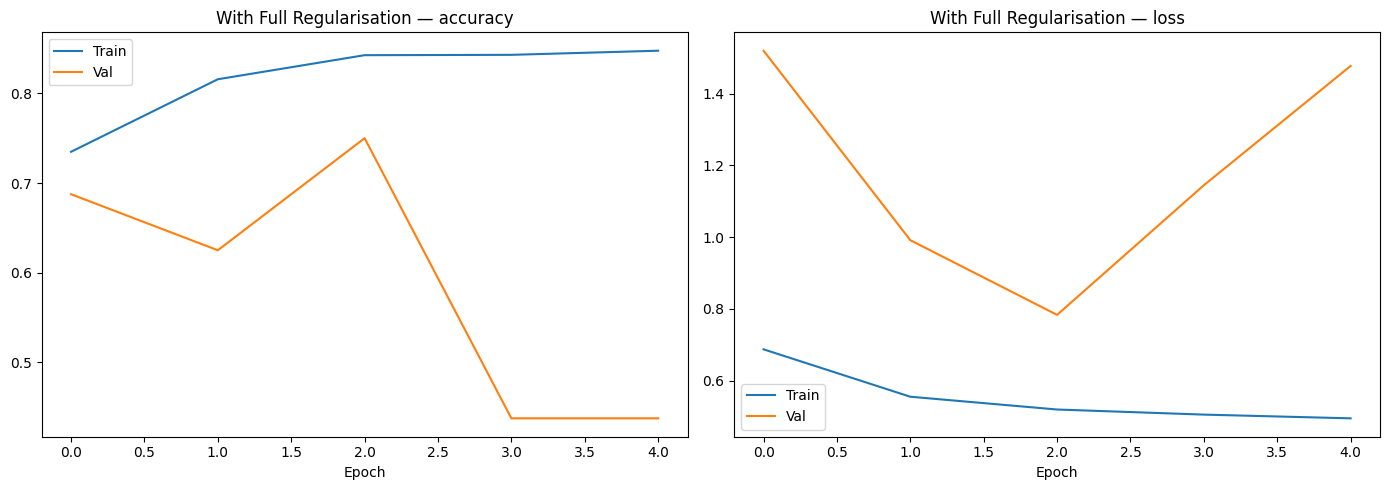

In [16]:
# TODO: train a model WITHOUT regularisation and one WITH full regularisation.
# Plot train loss vs val loss for each to visualise the overfitting gap.
# Use plot_history() from src.train.
## 3. Visualise Training vs Validation Loss Gap

# Train model WITHOUT regularisation
no_reg_model = build_advanced_nn(
    input_shape=(64, 64, 3),
    dropout_rate=0.0,
    l2_lambda=0.0,
    learning_rate=1e-3,
)

history_no_reg = train_model(
    no_reg_model,
    train_gen,
    val_gen,
    epochs=5,
    class_weights=class_weights,
)

# Plot training history for model without regularisation
plot_history(history_no_reg, title='Without Regularisation')


# Train model WITH full regularisation
full_reg_model = build_advanced_nn(
    input_shape=(64, 64, 3),
    dropout_rate=0.5,
    l2_lambda=1e-4,
    learning_rate=1e-3,
)

history_full_reg = train_model(
    full_reg_model,
    train_gen,
    val_gen,
    epochs=5,
    class_weights=class_weights,
)

# Plot training history for model with full regularisation
plot_history(history_full_reg, title='With Full Regularisation')

## 4. Reflection Questions

1. What is the vanishing gradient problem and how does Batch Normalization help?
2. Explain the difference between L1 and L2 regularisation. When would you prefer each?
3. How does Dropout prevent overfitting? What is its effect at inference time?
4. Why is gradient clipping important? What happens without it on deep networks?

### 1. Vanishing Gradient Problem and Batch Normalization

The vanishing gradient problem occurs when gradients become extremely small during backpropagation in deep neural networks. This causes earlier layers to learn very slowly or stop learning entirely.

Batch Normalization helps by normalizing layer activations during training, which improves gradient flow, speeds up convergence, and stabilizes learning.

**Observed in this project:**
- Training became more stable.
- Training accuracy improved to around **0.85–0.90**.
- Validation performance fluctuated less compared to the unregularized model.

---

### 2. Difference Between L1 and L2 Regularisation

#### L1 Regularisation
- Adds the absolute value of weights to the loss function.
- Produces sparse models by forcing some weights to zero.
- Useful for feature selection.

#### L2 Regularisation
- Adds the squared value of weights to the loss function.
- Reduces large weights smoothly without removing them completely.
- Helps improve generalization and training stability.

**Observed in this project:**
- The **L2 only** model achieved validation accuracy around **0.75**.
- The **No Regularisation** model showed stronger overfitting.
- **L2 regularisation** improved generalization performance.

---

### 3. How Dropout Prevents Overfitting and Its Effect During Inference

Dropout prevents overfitting by randomly disabling neurons during training. This forces the network to learn more generalized features instead of depending heavily on specific neurons.

**Observed in this project:**
- A dropout rate of **0.5** reduced the training-validation gap.
- The fully regularized model showed better generalization.

#### During Inference
- Dropout is automatically disabled.
- All neurons are used for prediction.
- TensorFlow/Keras scales outputs automatically for stable predictions.

---

### 4. Importance of Gradient Clipping

Gradient clipping prevents exploding gradients, where gradients become excessively large during backpropagation. Large gradients can cause unstable training, oscillating loss values, or failure to converge.

**Observed in this project:**
- Training remained stable across epochs.
- Loss decreased more smoothly.
- The optimizer performed controlled and stable weight updates.

Without gradient clipping, deep networks may experience unstable learning and poor convergence.